# Multivariate Time Series

So far we looked at one series at a time. But the interesting questions are about relationships: does the stock market lead the oil market, do two stocks share a trend we can trade, how many independent bets does a twenty-stock portfolio really contain?

This notebook covers three answers.

**1. VAR and Granger causality (sections 2 to 4).** Model several *stationary* series together, each as a function of the past of all of them. This describes lead-lag structure and how a shock spreads.

**2. Cointegration and pairs trading (sections 5 to 9).** Two *non-stationary* series can each be unpredictable random walks yet be tied together, so that some combination of them is stationary. This is the basis of relative-value trading, and the one idea here that becomes a real strategy.

**3. Principal component analysis (section 11).** Instead of modelling the dependence, decompose it, and find that a few factors explain most of a portfolio's movement.

One distinction runs through all of it, and getting it wrong is a classic error:

> **VAR needs stationary inputs. Cointegration is about non-stationary ones.**
>
> Fit a VAR to raw prices and you get a spurious regression: two unrelated random walks look strongly related just because both wander. So the VAR uses *returns*, which are stationary. Cointegration is the opposite search: for the rare case where a combination of non-stationary series *is* stationary. There we must use *prices*, since differencing to returns would destroy the relationship.

## 1. Data

Five liquid ETFs covering the main exposures, so any lead-lag structure has an economic reading rather than coming from overlapping holdings:

- **SPY**: S&P 500 (large-cap US equity)
- **QQQ**: Nasdaq 100 (tech growth)
- **IWM**: Russell 2000 (small-cap)
- **GLD**: gold
- **USO**: crude oil

Log returns in percent. The correlation heatmap is a first summary: the three equity ETFs move nearly together, gold is roughly independent, and oil sits in between.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, coint
import datetime
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Download data for multivariate time series analysis
print("Downloading market data...")
var_tickers = ['SPY', 'QQQ', 'IWM', 'GLD', 'USO']
var_data = yf.download(var_tickers, start='2016-01-01', end='2025-12-31', progress=False, auto_adjust=False)
var_prices = var_data['Adj Close'].dropna()

# Calculate log returns
var_returns = np.log(var_prices / var_prices.shift(1)).dropna() * 100

print(f"Sample period: {var_returns.index[0].date()} to {var_returns.index[-1].date()}")
print(f"Number of observations: {len(var_returns)}")
print(f"\nAssets: {list(var_returns.columns)}")

Sample period: 2016-01-05 to 2025-12-30
Number of observations: 2512

Assets: ['GLD', 'IWM', 'QQQ', 'SPY', 'USO']


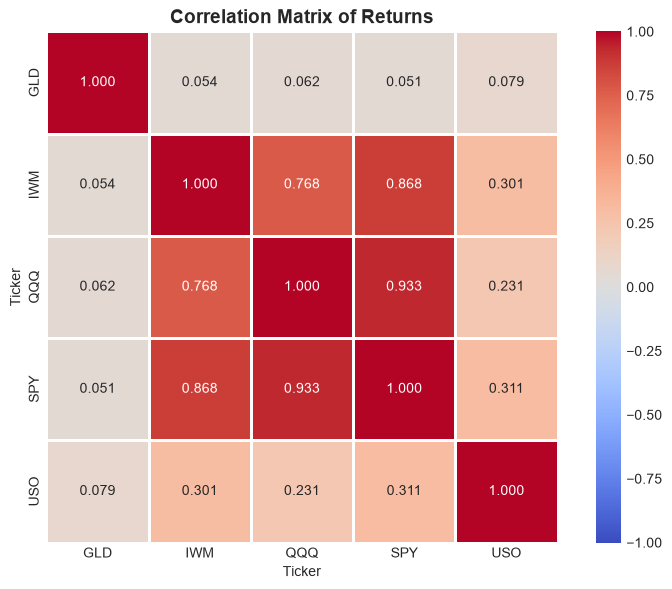

In [5]:
# Correlation
corr_matrix = var_returns.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=1)
plt.title('Correlation Matrix of Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Check stationarity before the VAR

Not a formality. A VAR on non-stationary data is a spurious regression, so its coefficients and impulse responses would be meaningless. Prices are $I(1)$, returns are $I(0)$, so we test the returns and expect a clear rejection of the unit-root null for each.

The ADF test is explained in section 3 of [ARIMA_engine.ipynb](ARIMA_engine.ipynb). Its null is a unit root; reject when the statistic is *more negative* than the critical value.

In [6]:
# Stationarity test (ADF)

adf_results = {}
for col in var_returns.columns:
    result = adfuller(var_returns[col].dropna(), maxlag=20, regression='c')
    adf_results[col] = {
        'statistic': result[0],
        'p-value': result[1],
        'lags': result[2],
        'critical_values': result[4]
    }
    
    print(f"\n{col}:")
    print(f"- ADF Statistic: {result[0]:.4f}")
    print(f"- p-value: {result[1]:.4f}")
    print(f"- Critical values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")

    if result[1] < 0.05:
        print(f'=> Stationary at 5% significance level')
    else:
        print(f'=> Non-stationary (may need differencing)')
        


GLD:
- ADF Statistic: -50.0277
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level

IWM:
- ADF Statistic: -16.3607
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level

QQQ:
- ADF Statistic: -16.6934
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level

SPY:
- ADF Statistic: -16.1889
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level

USO:
- ADF Statistic: -10.6701
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level


## 3. The VAR model

A **vector autoregression (VAR)** of order $p$ is an AR($p$) for a vector of series. With $\mathbf{y}_t = (y_{1t}, \dots, y_{kt})$,
$$
\mathbf{y}_t = \mathbf{c} + \Phi_1 \mathbf{y}_{t-1} + \cdots + \Phi_p \mathbf{y}_{t-p} + \boldsymbol{\varepsilon}_t .
$$
Each $\Phi_i$ is a full $k \times k$ matrix, so every series is regressed on the past of every series, including itself. That is $k^2 p + k$ coefficients. With $k=5$ and $p=9$ that is 230 parameters. Every extra lag costs $k^2 = 25$ more, which is why we pick the lag order with an information criterion rather than by hand.

Two points:

**Every equation has the same regressors,** so plain OLS equation by equation is efficient. This makes VARs cheap to fit.

**Same-period links live in the residual covariance $\Sigma$, not in the $\Phi_i$.** A VAR says nothing about how $y_{1t}$ and $y_{2t}$ move *within* the same period; that is all in $\Sigma$, which is not diagonal for financial data. This is the ambiguity that section 4 has to deal with.

**Lag choice.** AIC and BIC balance fit against the parameter count (penalty $\propto k^2$ per lag). AIC usually picks a longer lag, which is the safer side for forecasting.

In [7]:
# Fit VAR model

# Select lag order for using information criteria
model_temp = VAR(var_returns)
lag_order_results = model_temp.select_order(maxlags=15)
print(lag_order_results.summary())

# Use AIC
optimal_lag = lag_order_results.aic
print(f"\nOptimal lag order (AIC): {optimal_lag}")

# Fit VAR model
var_model = VAR(var_returns)
var_fit = var_model.fit(optimal_lag)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -0.3073    -0.2957*      0.7354    -0.3031*
1      -0.3259     -0.2559      0.7219     -0.3005
2      -0.3221     -0.1938      0.7247     -0.2755
3      -0.3284     -0.1418      0.7201     -0.2607
4      -0.3402    -0.09539      0.7116     -0.2513
5      -0.3389    -0.03574      0.7126     -0.2288
6      -0.3406     0.02083      0.7113     -0.2094
7      -0.3548     0.06493      0.7013     -0.2024
8      -0.3522      0.1258      0.7031     -0.1787
9     -0.3656*      0.1708     0.6938*     -0.1708
10     -0.3634      0.2312      0.6953     -0.1475
11     -0.3522      0.3007      0.7031     -0.1152
12     -0.3462      0.3650      0.7074    -0.08800
13     -0.3414      0.4282      0.7108    -0.06197
14     -0.3336      0.4942      0.7164    -0.03305
15     -0.3300      0.5561      0.7190   -0.008314
-------------------------------

## 4. Granger causality, and a testing trap

Granger's definition is modest, and the word "causality" promises more than the test gives.

> $X$ **Granger-causes** $Y$ if the past of $X$ helps predict $Y$ beyond $Y$'s own past.

That is all: extra predictive power, not mechanism. We compare two regressions of $y_t$, one on its own lags and one that also adds the lags of $x$, and test whether the $x$ coefficients are jointly zero with an $F$ test.

**What it does not mean.** A hidden common driver of both $X$ and $Y$ can produce Granger causality with no real link. If $X$ is simply reported faster than $Y$, it will "cause" $Y$. And the test is linear, so it misses nonlinear links.

### The trap: taking the smallest p-value across lags

`grangercausalitytests` returns one test per lag from $1$ to `maxlag`. It is tempting to report the smallest p-value across them. But the minimum of $m$ p-values is not a p-value. If each is uniform under the null, the chance that at least one of $m$ falls below $0.05$ is about $1 - 0.95^m$, which for $m = 9$ is about **37%**, not 5%.

The effect here is large. Taking the minimum over nine lags flags **14 of 20 pairs** as causal. The correct single joint test at the chosen lag gives **9**. The search invented five. The earlier version took the minimum; it is fixed below.

The right way: fix the lag first (from the VAR), then run one joint $F$ test at that lag. That already asks whether the lags of $X$ add anything, once.

Joint F test at the VAR's chosen lag (9):
  significant pairs: 9 / 20   <- correct

Minimum p-value scanned across lags 1..9:
  significant pairs: 14 / 20   <- INFLATED by the search

The search alone manufactures 5 of them. Under H0, the chance
that at least one of 9 tests falls below 0.05 is 1 - 0.95^9 = 37%, not 5%.


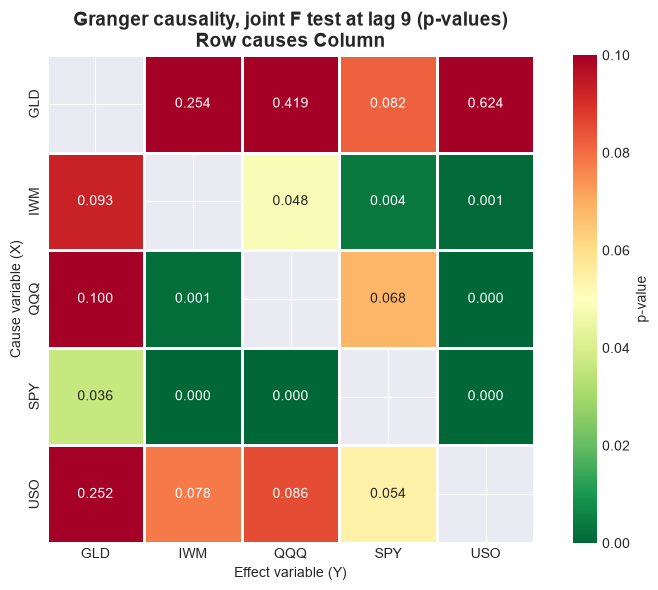


A p-value below 0.05 means the lags of X collectively improve the forecast of Y.
It does NOT mean X causes Y in any mechanical sense: a common driver, or simply
faster reporting of X, produces the same signature.


In [8]:
# Granger causality: does the past of X help predict Y, beyond Y's own past?
#
# A NOTE ON MULTIPLE TESTING, which is the whole reason this cell is written the way it is.
# grangercausalitytests() returns one test per lag from 1 to maxlag. Scanning them and
# reporting the SMALLEST p-value is not a valid procedure: the minimum of m p-values is
# not a p-value. Under H0 each is uniform on [0,1], so P(at least one of m below 0.05)
# is about 1 - 0.95^m, which for m = 9 is ~37%, not 5%.
#
# The correct procedure: fix the lag order FIRST (the VAR's AIC choice, above), then run
# ONE joint F test at that lag. The joint test already asks whether the p lags of X add
# anything collectively, which is exactly the question.

import io, contextlib

lag = max(1, int(optimal_lag))
granger_results = pd.DataFrame(index=var_returns.columns, columns=var_returns.columns,
                               dtype=float)
min_pvalue_results = pd.DataFrame(index=var_returns.columns, columns=var_returns.columns,
                                  dtype=float)   # kept only to demonstrate the inflation

for cause in var_returns.columns:
    for effect in var_returns.columns:
        if cause == effect:
            continue
        # grangercausalitytests tests whether the SECOND column causes the FIRST.
        test_data = var_returns[[effect, cause]]
        with contextlib.redirect_stdout(io.StringIO()):        # it prints a wall of text
            gc = grangercausalitytests(test_data, maxlag=lag)

        granger_results.loc[cause, effect] = gc[lag][0]['ssr_ftest'][1]     # the joint test
        min_pvalue_results.loc[cause, effect] = min(
            gc[k][0]['ssr_ftest'][1] for k in range(1, lag + 1))            # the trap

n_correct = int((granger_results < 0.05).sum().sum())
n_inflated = int((min_pvalue_results < 0.05).sum().sum())
n_pairs = len(var_returns.columns) * (len(var_returns.columns) - 1)

print(f"Joint F test at the VAR's chosen lag ({lag}):")
print(f"  significant pairs: {n_correct} / {n_pairs}   <- correct")
print(f"\nMinimum p-value scanned across lags 1..{lag}:")
print(f"  significant pairs: {n_inflated} / {n_pairs}   <- INFLATED by the search")
print(f"\nThe search alone manufactures {n_inflated - n_correct} of them. Under H0, the chance")
print(f"that at least one of {lag} tests falls below 0.05 is 1 - 0.95^{lag} = "
      f"{1 - 0.95**lag:.0%}, not 5%.")

plt.figure(figsize=(8, 6))
mask = np.eye(len(granger_results), dtype=bool)     # hide the diagonal
sns.heatmap(granger_results, annot=True, fmt='.3f', cmap='RdYlGn_r',
            mask=mask, vmin=0, vmax=0.1, square=True, linewidths=1,
            cbar_kws={'label': 'p-value'})
plt.title(f'Granger causality, joint F test at lag {lag} (p-values)\nRow causes Column',
          fontsize=14, fontweight='bold')
plt.xlabel('Effect variable (Y)')
plt.ylabel('Cause variable (X)')
plt.tight_layout()
plt.show()

print("\nA p-value below 0.05 means the lags of X collectively improve the forecast of Y.")
print("It does NOT mean X causes Y in any mechanical sense: a common driver, or simply")
print("faster reporting of X, produces the same signature.")

## 5. Impulse responses and the identification problem

The individual VAR coefficients say little on their own. The **impulse response function** is what we actually read: if one variable gets a one-off shock today, what happens to another over the next $h$ days? It comes from rewriting the VAR as a weighted sum of past shocks.

### The difficulty

The residual covariance $\Sigma$ is not diagonal: SPY and QQQ shocks are correlated at about $0.9$. So "a shock to SPY with QQQ held fixed" never happens in the data, and the raw responses have no clean reading.

The usual fix is to **orthogonalise** with a Cholesky factorisation, which turns the correlated shocks into uncorrelated ones that can be hit one at a time. But this imposes an **order**: the first variable is affected by nothing else within the day, the second only by the first, and so on. The order is an *assumption* by the modeller, not a finding. Reorder the variables and the responses change: with SPY first, an SPY shock hits QQQ instantly; with QQQ first, it reverses. The data cannot decide.

This is the **identification problem**. The plots show both the raw responses (honest but not causal) and the orthogonalised ones with SPY first. That order assumes the broad market moves first and the rest respond within the day. It is defensible for these assets, but it is still an assumption.

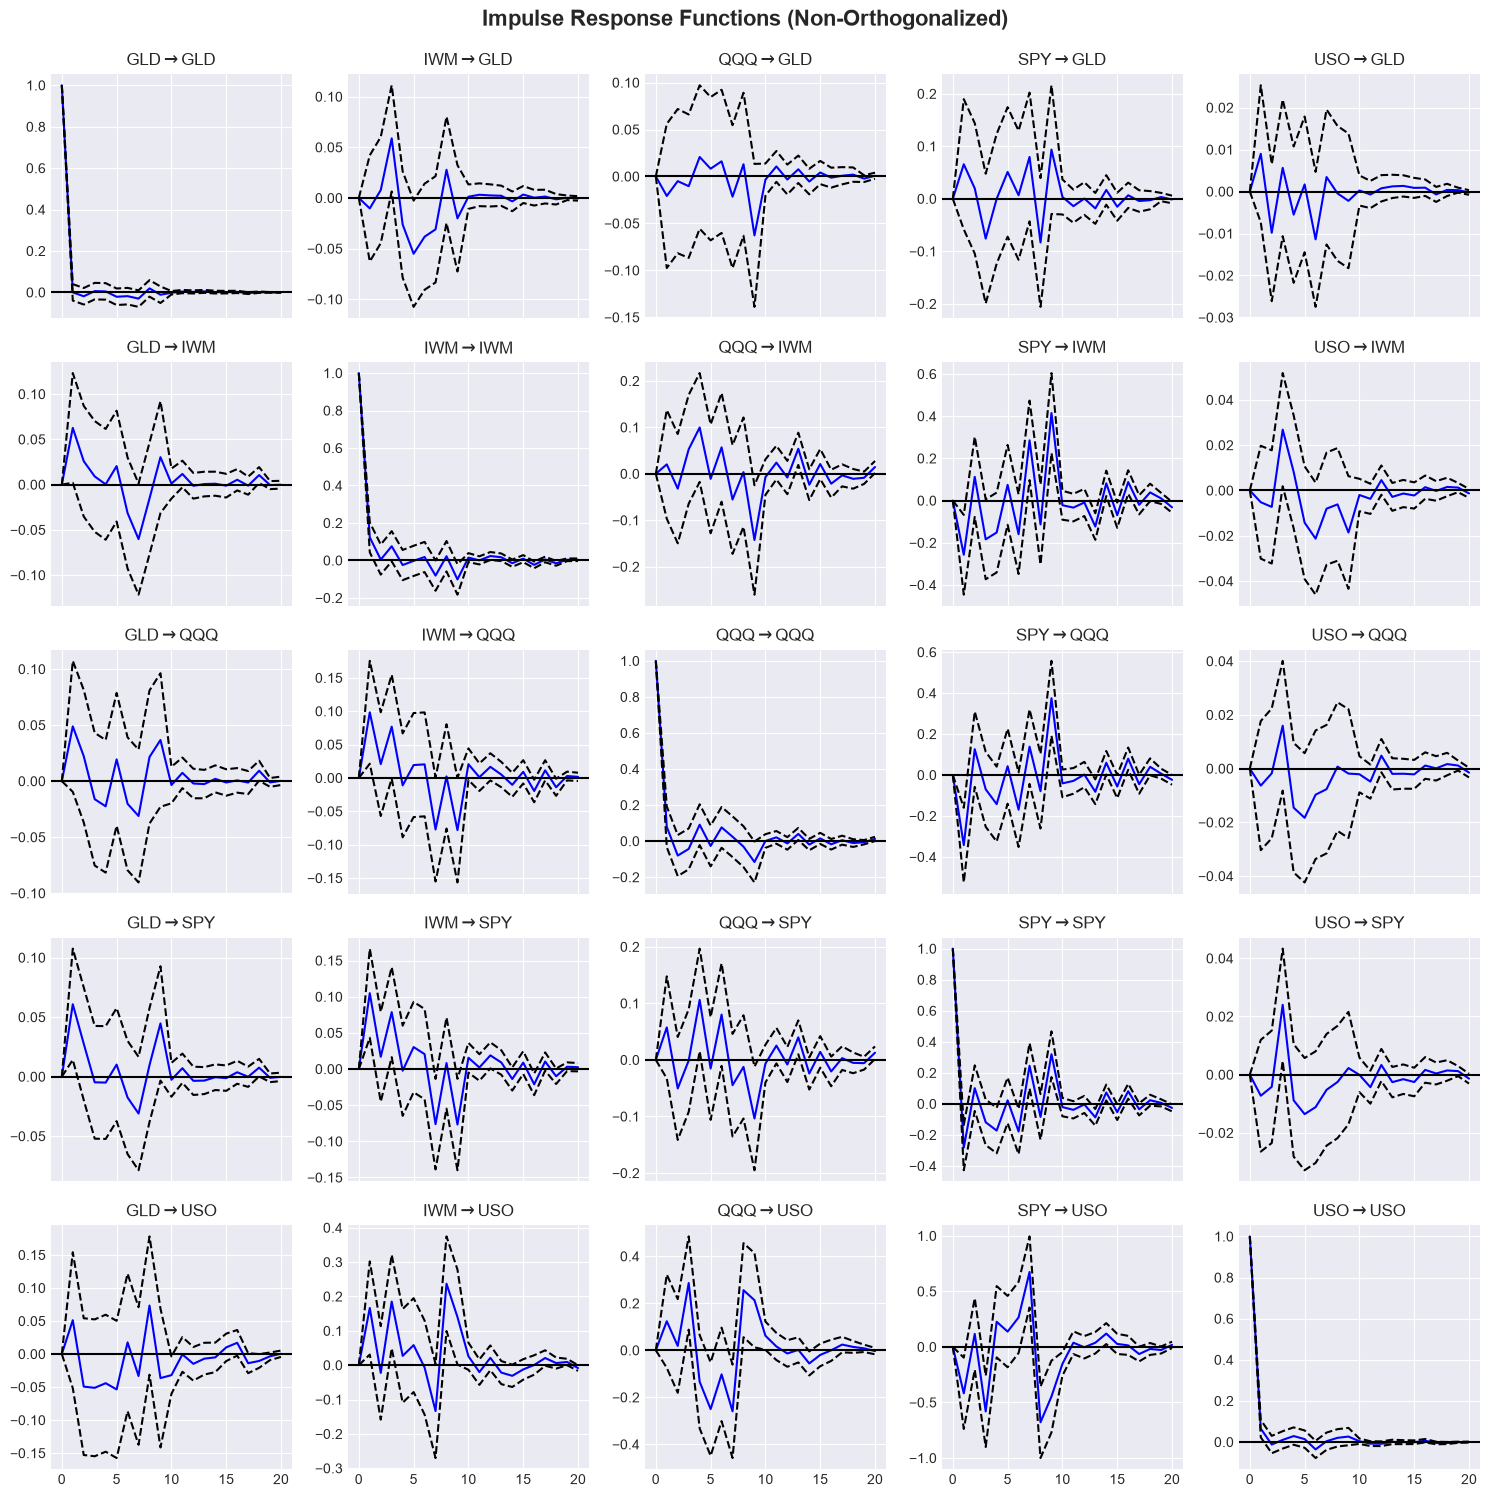

In [9]:
# Compute impulse response functions
irf = var_fit.irf(periods=20)

# Plot IRFs
fig = irf.plot(orth=False, figsize=(15, 15)) # orth: whether to use orthogonalized shocks (via Cholesky decomposition)
                                             # plot_stderr defaults to True; to display error bands
plt.suptitle('Impulse Response Functions (Non-Orthogonalized)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Plot orthogonalized IRFs (Cholesky decomposition)
#fig = irf.plot(orth=True, figsize=(16, 20)) 
#plt.suptitle('Impulse Response Functions (Orthogonalized - Cholesky)', fontsize=16, fontweight='bold', y=0.995) # Set the suptitle near the top (y=0.995)
#plt.tight_layout()
#plt.show()

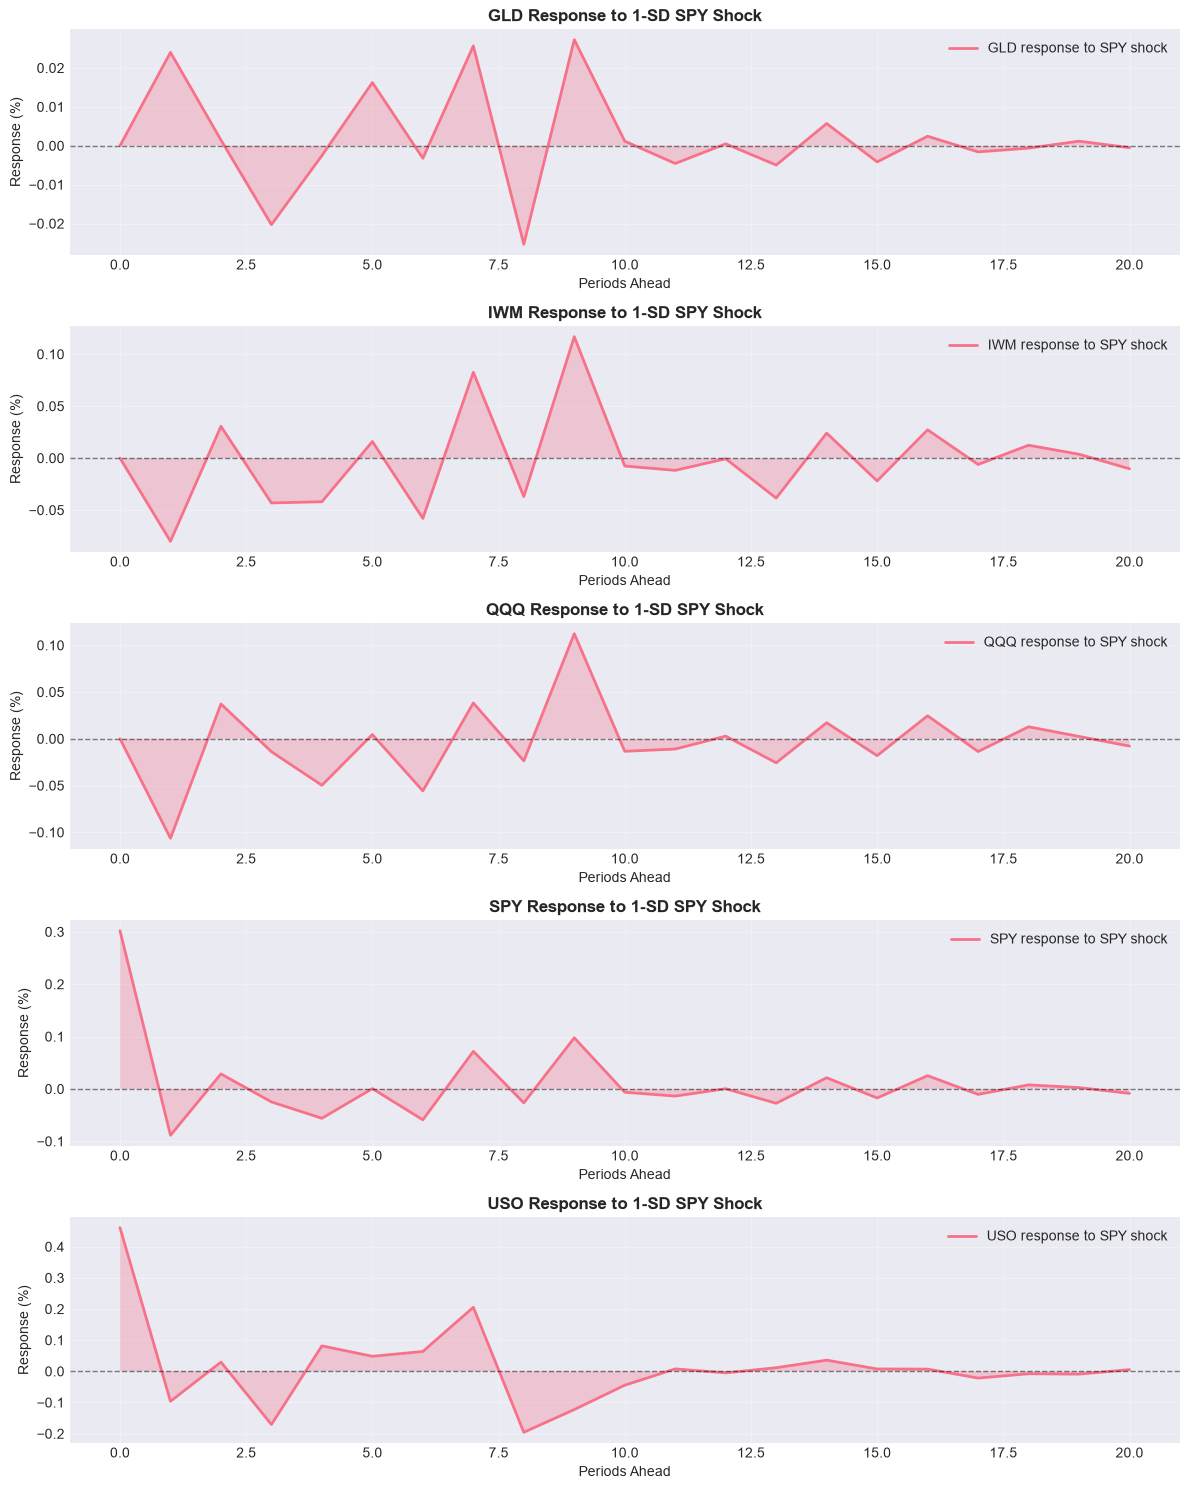


Cumulative Responses to 1-SD SPY Shock (after 10 days):
- GLD: 0.0432%
- IWM: -0.0143%
- QQQ: -0.0569%
- SPY: 0.2455%
- USO: 0.3043%


In [10]:
# On specific shock transmission: SPY shock → other markets

periods = 20
irf = var_fit.irf(periods=periods)

# Extract IRF data for SPY shocks
spy_shock_idx = list(var_returns.columns).index('SPY')
responses = irf.orth_irfs[:, :, spy_shock_idx] # orthogonalized impulse response functions (OIRFs) using Cholesky decomposition
# irf.orth_irfs returns an array, with dimensions (periods, num_variables, num_variables), where index [t, i, j] represents the effect of a shock in variable j on variable i at time t.
# It returns the effect of a one-standard-deviation innovation on variables over time. 
# This means the orthogonalized innovations are scaled to have a variance equal to one (or the shocks are scaled by the standard deviation), not that the function returns the standard deviation as an output value. 

fig, axes = plt.subplots(len(var_returns.columns), 1, figsize=(12, 15))

for i, col in enumerate(var_returns.columns):
    response = responses[:, i]
    
    axes[i].plot(response, linewidth=2, label=f'{col} response to SPY shock')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[i].fill_between(range(periods+1), 0, response, alpha=0.3)
    axes[i].set_title(f'{col} Response to 1-SD SPY Shock', fontweight='bold')
    axes[i].set_xlabel('Periods Ahead')
    axes[i].set_ylabel('Response (%)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Calculate cumulative responses
print("\nCumulative Responses to 1-SD SPY Shock (after 10 days):")
for i, col in enumerate(var_returns.columns):
    cumulative_response = responses[:10, i].sum()
    print(f"- {col}: {cumulative_response:.4f}%")

## 6. Cointegration

The idea is surprising at first. Two series can each be $I(1)$, wandering without returning to a mean and individually unforecastable, yet be tied together so that some combination of them *is* stationary. Formally, $x_t$ and $y_t$ are **cointegrated** if both are $I(1)$ but
$$
z_t = y_t - \beta\, x_t
$$
is stationary. We call $z_t$ the **spread**.

The meaning: the two assets share a common trend, driven by the same random walk, and the spread is what is left after removing it. They can wander far from any fixed level while the *gap between them* stays bounded and mean-reverting. Two ships drifting on the same current, tied together.

**Why this is tradeable.** Each price is a random walk, so its next move is unforecastable and there is nothing to trade. But the spread is stationary, and a stationary series reverts to its mean by definition: when it strays, it comes back. So we trade the spread, not the prices.

This connects to the VAR through the **Granger representation theorem**: if two series are cointegrated, a VAR in their differences is wrong, and the correct model adds the level of last period's spread as a regressor. Differencing to returns throws that term away. That is why cointegration must be tested on *prices*.

### The Engle-Granger two steps

1. **Check both series are $I(1)$** with an ADF test in levels. If one is already stationary, cointegration is the wrong frame.
2. **Estimate $\beta$ by OLS**, regressing $y_t$ on $x_t$. This estimate is unusually accurate, because a wrong $\beta$ leaves a random walk in the residual, which the fit strongly penalises.
3. **Test the residual for a unit root.** If the spread is stationary, the pair is cointegrated. The critical values are not the usual ADF ones (because $\beta$ was estimated on the same data); `statsmodels.coint` uses the correct ones. Null: no cointegration.

Two limits. Engle-Granger is **asymmetric** (regressing $y$ on $x$ vs $x$ on $y$ can differ), and it finds at most **one** relationship. For three or more series use Johansen's procedure.

In [11]:
# Download pairs of stocks for cointegration analysis
print("Downloading pairs of related stocks...")

# Financial sector pairs
pairs = {
    'Banks': ['JPM', 'BAC'],
    'Tech': ['MSFT', 'GOOGL'],
    'Oil': ['XOM', 'CVX'],
    'Retail': ['WMT', 'TGT']
}

pair_data = {}
for sector, tickers in pairs.items():
    data = yf.download(tickers, start='2023-01-01', end='2025-12-31', progress=False, auto_adjust=False)
    pair_data[sector] = data['Adj Close'].dropna()
    print(f"- {sector}: {tickers[0]} vs {tickers[1]} - {len(pair_data[sector])} observations")

- Banks: JPM vs BAC - 751 observations
- Tech: MSFT vs GOOGL - 751 observations
- Oil: XOM vs CVX - 751 observations
- Retail: WMT vs TGT - 751 observations


In [12]:
# Test for cointegration using Engle-Granger method

cointegration_results = {}

for sector, data in pair_data.items():
    ticker1, ticker2 = data.columns[0], data.columns[1]
    series1 = data[ticker1]
    series2 = data[ticker2]
    
    print(f"\n{sector}: {ticker1} vs {ticker2}")
    print("-" * 50)
    
    # Step 1: Test for unit roots in levels
    adf1 = adfuller(series1, maxlag=20, regression='c')
    adf2 = adfuller(series2, maxlag=20, regression='c')
    
    print(f"\nStep 1: Unit Root Tests (Levels)")
    print(f"- {ticker1}: ADF = {adf1[0]:.4f}, p-value = {adf1[1]:.4f}")
    print(f"- {ticker2}: ADF = {adf2[0]:.4f}, p-value = {adf2[1]:.4f}")
    
    if adf1[1] > 0.05 and adf2[1] > 0.05:
        print("=> Both series are non-stationary (suitable for cointegration test)")
    
    # Step 2: Test for cointegration
    # Null Hypothesis (H₀): the two time series are not cointegrated (they do not share a common stochastic trend).
    # Alternative Hypothesis (H₁): the two time series are cointegrated (they move together in the long run).
    coint_stat, coint_pval, critical_values = coint(series1, series2)
    # coint_stat: the t-statistic of the unit-root test on the residuals of the regression
    # coint_pval: MacKinnon's approximate asymptotic p-value
    # critical_values: a dictionary of critical values for the test at the 1%, 5%, and 10% levels
    
    print(f"\nStep 2: Cointegration Test (Engle-Granger)")
    print(f"- Test statistic: {coint_stat:.4f}")
    print(f"- p-value: {coint_pval:.4f}")
    print(f"- Critical values:")
    for i, level in enumerate([0.1, 0.05, 0.01]):
        print(f"    {level*100:.0f}%: {critical_values[i]:.4f}")
    
    if coint_pval < 0.05:
        print(f"=> Series are COINTEGRATED at 5% significance level")
        cointegrated = True
    else:
        print(f"=> Series are NOT cointegrated at 5% significance level")
        cointegrated = False
    
    cointegration_results[sector] = {
        'tickers': [ticker1, ticker2],
        'statistic': coint_stat,
        'p-value': coint_pval,
        'cointegrated': cointegrated
    }


Banks: BAC vs JPM
--------------------------------------------------

Step 1: Unit Root Tests (Levels)
- BAC: ADF = -0.0967, p-value = 0.9498
- JPM: ADF = 0.1824, p-value = 0.9713
=> Both series are non-stationary (suitable for cointegration test)

Step 2: Cointegration Test (Engle-Granger)
- Test statistic: -2.7865
- p-value: 0.1700
- Critical values:
    10%: -3.9111
    5%: -3.3443
    1%: -3.0501
=> Series are NOT cointegrated at 5% significance level

Tech: GOOGL vs MSFT
--------------------------------------------------

Step 1: Unit Root Tests (Levels)
- GOOGL: ADF = 1.0668, p-value = 0.9949
- MSFT: ADF = -1.7761, p-value = 0.3924
=> Both series are non-stationary (suitable for cointegration test)

Step 2: Cointegration Test (Engle-Granger)
- Test statistic: -0.0118
- p-value: 0.9856
- Critical values:
    10%: -3.9111
    5%: -3.3443
    1%: -3.0501
=> Series are NOT cointegrated at 5% significance level

Oil: CVX vs XOM
--------------------------------------------------

Step

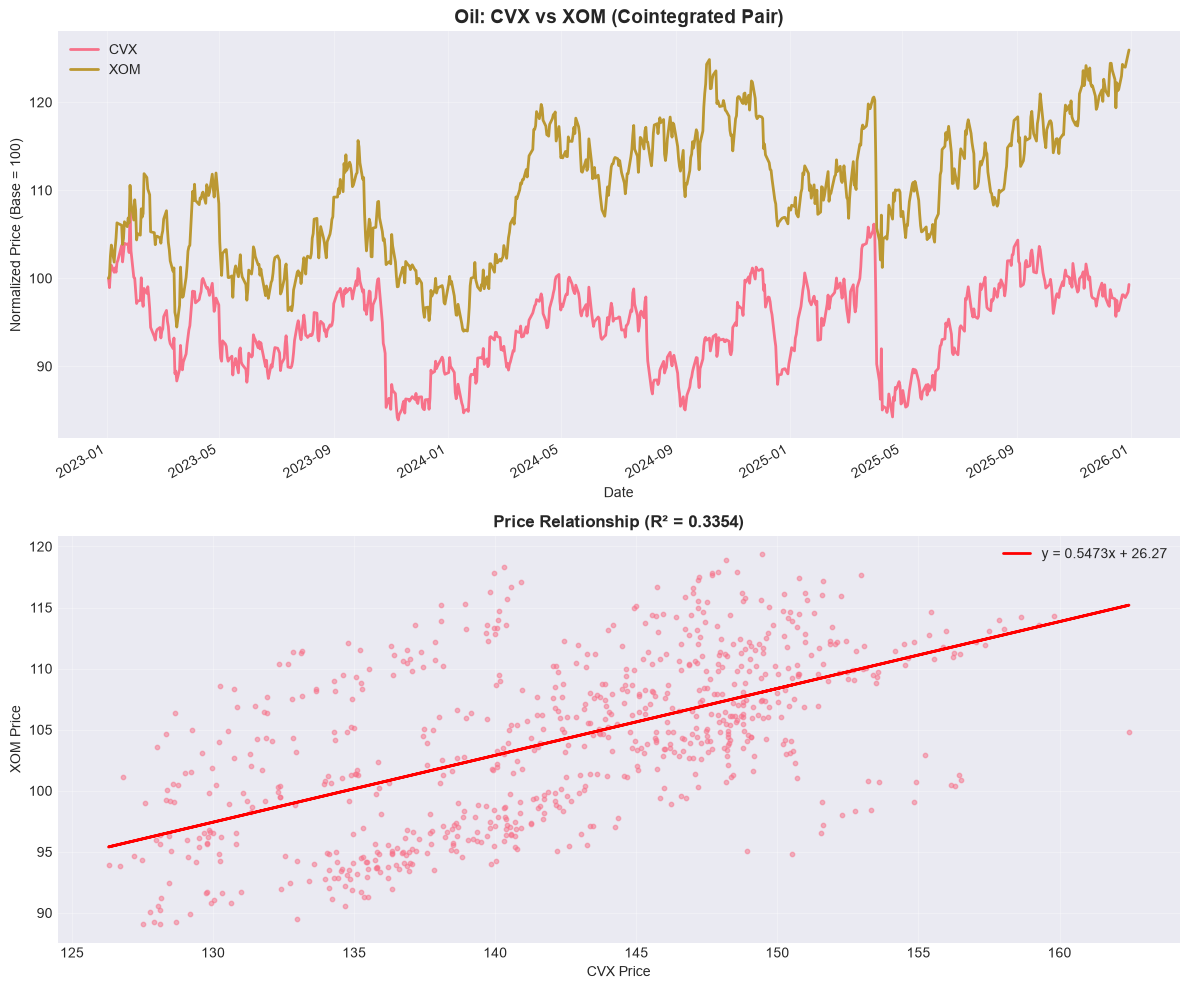

In [13]:
# Visualize price relationships for cointegrated pairs
for sector, result in cointegration_results.items():
    if result['cointegrated']:
        ticker1, ticker2 = result['tickers']
        data = pair_data[sector]
        
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot normalized prices
        norm_prices = data / data.iloc[0] * 100
        norm_prices.plot(ax=axes[0], linewidth=2)
        axes[0].set_title(f'{sector}: {ticker1} vs {ticker2} (Cointegrated Pair)', 
                         fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Normalized Price (Base = 100)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot scatter with regression line
        from scipy import stats as sp_stats
        slope, intercept, r_value, p_value, std_err = sp_stats.linregress(data[ticker1], data[ticker2])
        
        axes[1].scatter(data[ticker1], data[ticker2], alpha=0.5, s=10)
        axes[1].plot(data[ticker1], intercept + slope * data[ticker1], 
                    'r-', linewidth=2, label=f'y = {slope:.4f}x + {intercept:.2f}')
        axes[1].set_xlabel(f'{ticker1} Price')
        axes[1].set_ylabel(f'{ticker2} Price')
        axes[1].set_title(f'Price Relationship (R² = {r_value**2:.4f})', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## 7. Pairs trading: the strategy

Now we turn the statistics into a trade. The spread is stationary, so it reverts, so when it strays we bet it comes back.

**Step 1: hedge ratio.** Regress $P_2$ on $P_1$ over the *training* period only to get $\hat\beta$. We hold one unit of asset 2 and short $\hat\beta$ of asset 1, giving the spread
$$
S_t = P_{2,t} - \hat\beta\, P_{1,t} .
$$
Fitting $\hat\beta$ on training data only matters: using the full sample would leak future information into the position sizing.

**Step 2: standardise.** The dollar spread drifts, so we use a rolling $z$-score
$$
z_t = \frac{S_t - \text{mean}_t}{\text{std}_t},
$$
over a trailing 60-day window. Long enough to estimate the mean and variance, short enough to adapt. A trailing window uses no future data, so this is tradeable.

**Step 3: the rules.** Enter at $\lvert z\rvert = 2$, exit at $\lvert z\rvert = 0.5$:

| Condition | Action |
|---|---|
| $z_t < -2$ | long the spread (buy 2, short 1): it is low, should rise |
| $z_t > +2$ | short the spread (sell 2, buy 1): it is high, should fall |
| $\lvert z_t\rvert < 0.5$ | flat: it has reverted, take profit |

Why exit at $0.5$, not $0$? Waiting for a full return to the mean is greedy: the spread often gets most of the way back then wanders off, and the last half standard deviation is the least reliable part. Exiting early also shortens the holding period and the exposure to the relationship breaking.

**The risk no backtest shows.** Cointegration holds in a sample, not forever. Relationships break: firms merge, business models diverge. When a pair *stops* being cointegrated, the spread trends instead of reverting, and a mean-reversion strategy keeps buying into a losing position as it gets worse. This is how pairs trading blows up, and in-sample statistics do not protect against it.

In [14]:
# Pairs Trading Strategy

# We implement a complete pairs trading strategy with:
# 1. Hedge ratio (beta) using OLS
# 2. Spread and z-score calculation
# 3. Trading signals based on spread deviation
# 4. Transaction costs and slippage
# 5. Performance metrics

# Select the most cointegrated pair for trading
best_pair_sector = min(cointegration_results.items(), 
                       key=lambda x: x[1]['p-value'] if x[1]['cointegrated'] else 1.0)
best_pair_sector = best_pair_sector[0] # returns sector name

print(f"Selected pair for trading: {best_pair_sector}")
print(f"- Tickers: {cointegration_results[best_pair_sector]['tickers']}")
print(f"- Cointegration p-value: {cointegration_results[best_pair_sector]['p-value']:.4f}")

# Get the data
trading_data = pair_data[best_pair_sector].copy()
ticker1, ticker2 = trading_data.columns[0], trading_data.columns[1]
price1 = trading_data[ticker1]
price2 = trading_data[ticker2]

Selected pair for trading: Oil
- Tickers: ['CVX', 'XOM']
- Cointegration p-value: 0.0198


In [15]:
# Step 1: Estimate hedge ratio using OLS regression
# We regress price2 on price1 to find the beta
from sklearn.linear_model import LinearRegression

# Use training period (first 70% of data)
train_size = int(len(trading_data) * 0.7)
train_data = trading_data.iloc[:train_size]
test_data = trading_data.iloc[train_size:]

print(f"\nData Split:")
print(f"- Training: {train_data.index[0].date()} to {train_data.index[-1].date()} ({len(train_data)} obs)")
print(f"- Testing:  {test_data.index[0].date()} to {test_data.index[-1].date()} ({len(test_data)} obs)")

# Estimate hedge ratio on training data
X_train = train_data[ticker1].values.reshape(-1, 1) # The training data (independent variables), which should be a 2D array or matrix
y_train = train_data[ticker2].values # The target values (dependent variable), typically a 1D array or similar

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

hedge_ratio = lr_model.coef_[0]
intercept = lr_model.intercept_

print(f"\nHedge Ratio Estimation (OLS): {ticker2} = {intercept:.4f} + {hedge_ratio:.4f} × {ticker1}")
print(f"=> Interpretation: Short ${hedge_ratio:.2f} of {ticker2} for every $1 long in {ticker1}")


Data Split:
- Training: 2023-01-03 to 2025-02-05 (525 obs)
- Testing:  2025-02-06 to 2025-12-30 (226 obs)

Hedge Ratio Estimation (OLS): XOM = 32.6080 + 0.4948 × CVX
=> Interpretation: Short $0.49 of XOM for every $1 long in CVX


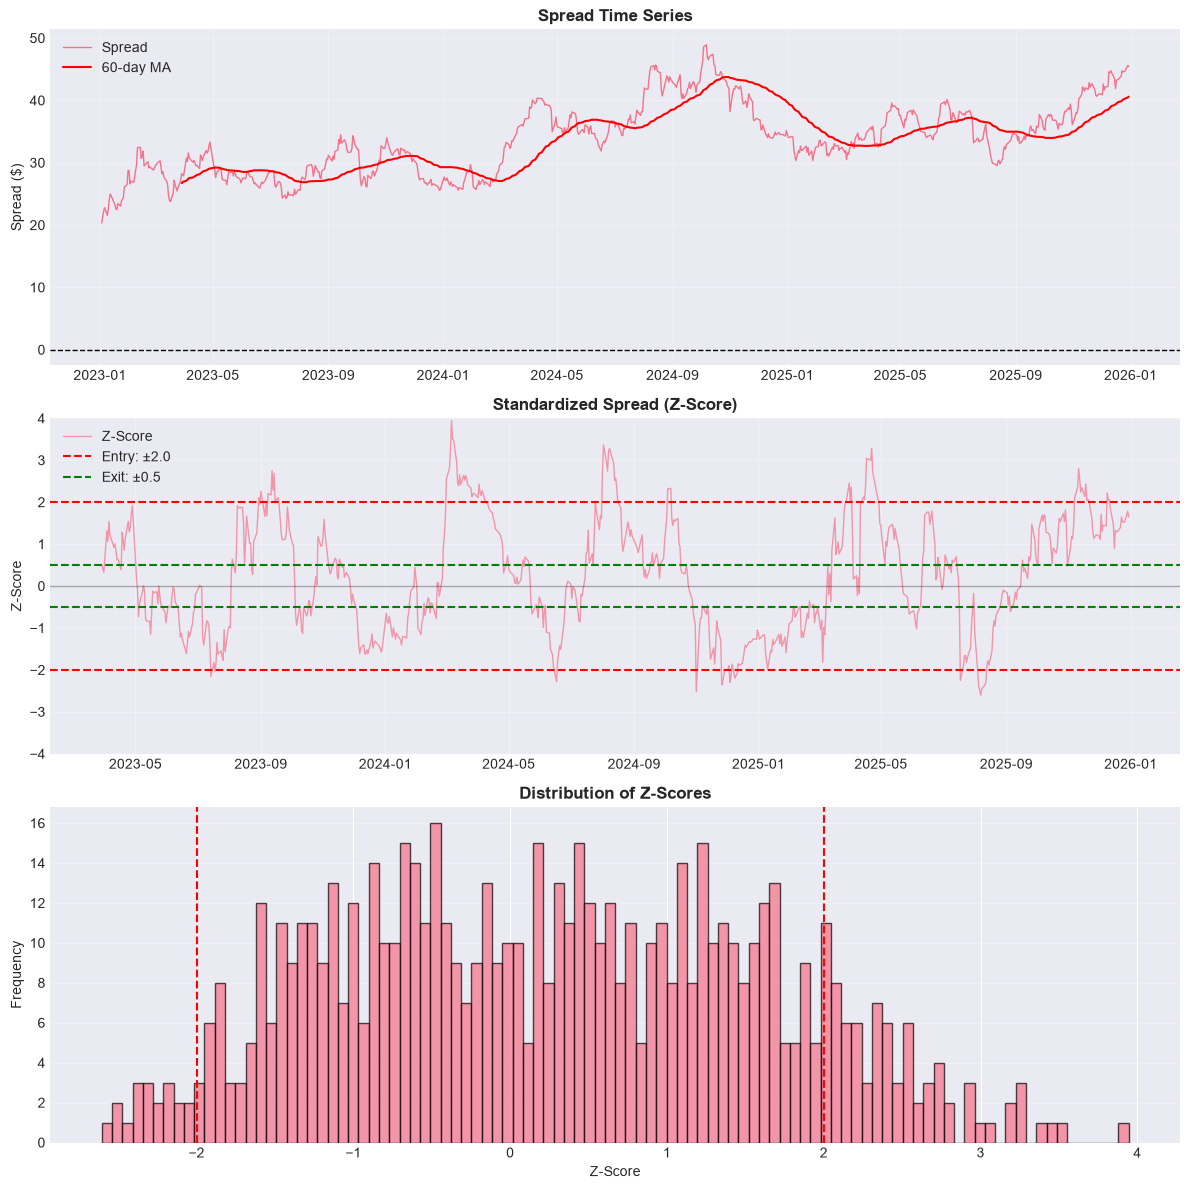


Spread Statistics (Full Period):
- Mean: 33.7491
- Std Dev: 5.6574
- Min: 20.3137
- Max: 48.9313


In [16]:
# Step 2: Construct the spread series
# Spread = price2 - hedge_ratio * price1

spread = price2 - hedge_ratio * price1 # alternative: spread between log prices has better statistical properties
spread_train = spread.iloc[:train_size]
spread_test = spread.iloc[train_size:]

# Calculate z-score of the spread (standardized spread)
# Use rolling window for adaptive mean and std
lookback_window = 60  # 60-day rolling window

spread_mean = spread.rolling(window=lookback_window).mean()
spread_std = spread.rolling(window=lookback_window).std()
z_score = (spread - spread_mean) / spread_std

# Visualize spread and z-score
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Raw spread
axes[0].plot(spread.index, spread, linewidth=1, label='Spread')
axes[0].plot(spread_mean.index, spread_mean, linewidth=1.5, 
            label=f'{lookback_window}-day MA', color='red')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
#axes[0].axvline(x=test_data.index[0], color='green', linestyle='--', linewidth=2, label='Test Period Start')
axes[0].set_title('Spread Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Spread ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Z-score with entry/exit thresholds
entry_threshold = 2.0
exit_threshold = 0.5

axes[1].plot(z_score.index, z_score, linewidth=1, label='Z-Score', alpha=0.7)
axes[1].axhline(y=entry_threshold, color='red', linestyle='--', 
               linewidth=1.5, label=f'Entry: ±{entry_threshold}')
axes[1].axhline(y=-entry_threshold, color='red', linestyle='--', linewidth=1.5)
axes[1].axhline(y=exit_threshold, color='green', linestyle='--', 
               linewidth=1.5, label=f'Exit: ±{exit_threshold}')
axes[1].axhline(y=-exit_threshold, color='green', linestyle='--', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
#axes[1].axvline(x=test_data.index[0], color='green', linestyle='--', linewidth=2, label='Test Period Start')
axes[1].set_title('Standardized Spread (Z-Score)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Z-Score')
axes[1].set_ylim([-4, 4])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Distribution of z-scores
axes[2].hist(z_score.dropna(), bins=100, alpha=0.7, edgecolor='black')
axes[2].axvline(x=entry_threshold, color='red', linestyle='--', linewidth=1.5)
axes[2].axvline(x=-entry_threshold, color='red', linestyle='--', linewidth=1.5)
#axes[2].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[2].set_title('Distribution of Z-Scores', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Z-Score')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nSpread Statistics (Full Period):")
print(f"- Mean: {spread.mean():.4f}")
print(f"- Std Dev: {spread.std():.4f}")
print(f"- Min: {spread.min():.4f}")
print(f"- Max: {spread.max():.4f}")


Trading Signals (Test Period):
- Entry threshold: ±2.0 std devs
- Exit threshold: ±0.5 std devs
- Number of trades: 10
- Long positions: 27 days
- Short positions: 67 days
- Flat positions: 132 days


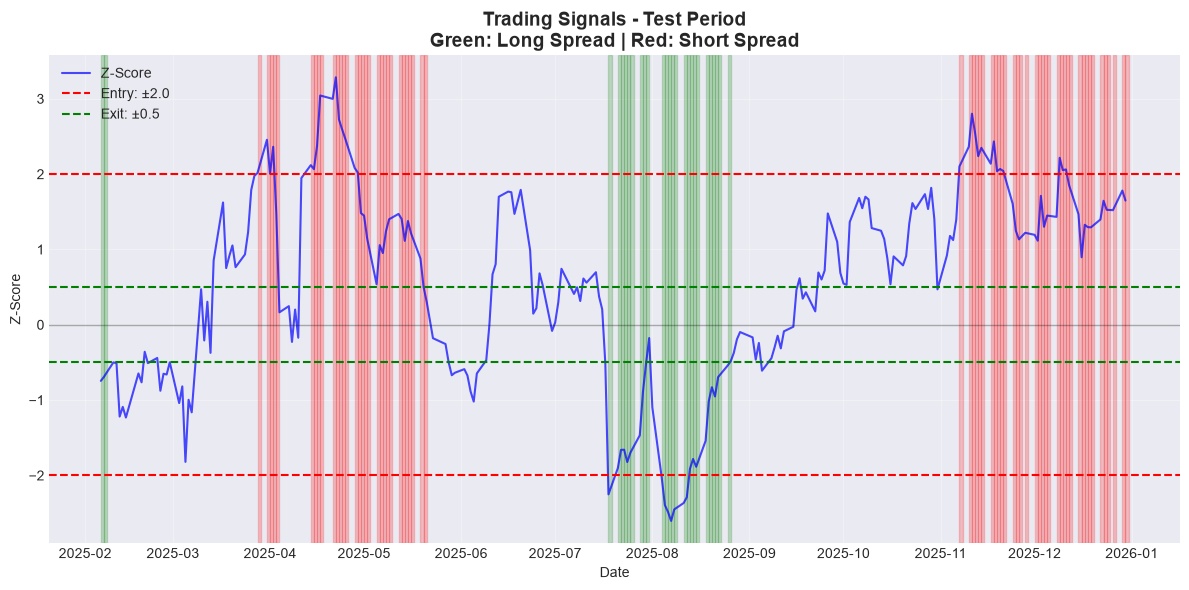

In [17]:
# Step 3: Generate trading signals
# Entry: |z-score| > entry_threshold
# Exit: |z-score| < exit_threshold
# Position (recall Spread = Price of stock2 - hedge_ratio * Price of stock1, where we regress stock2 on stock1): 
#  - Long spread (long stock2, short stock1) when z-score < -entry_threshold
#  - Short spread (short stock2, long stock1) when z-score > entry_threshold

def generate_signals(z_score, entry_threshold=2.0, exit_threshold=0.5):
    """
    Generate trading signals based on z-score
    Returns:
        signals: 1 (long spread), -1 (short spread), 0 (no position)
    """
    signals = pd.Series(0, index=z_score.index)
    position = 0 # Current position
    
    for i in range(1, len(z_score)):
        if pd.isna(z_score.iloc[i]):
            signals.iloc[i] = position
            continue
        
        z = z_score.iloc[i]
        
        # Entry signals
        if position == 0:
            if z < -entry_threshold:
                position = 1 # Long spread
            elif z > entry_threshold:
                position = -1 # Short spread
        
        # Exit signals
        elif position == 1: # Currently long spread
            if z > -exit_threshold:
                position = 0 # Close position
        
        elif position == -1: # Currently short spread
            if z < exit_threshold:
                position = 0 # Close position
        
        signals.iloc[i] = position
    
    return signals

# Generate signals for test period only
signals = generate_signals(z_score, entry_threshold=entry_threshold, exit_threshold=exit_threshold)
signals_test = signals.loc[test_data.index]

# Count trades
position_changes = signals_test.diff().abs()
num_trades = (position_changes > 0).sum()

print(f"\nTrading Signals (Test Period):")
print(f"- Entry threshold: ±{entry_threshold} std devs")
print(f"- Exit threshold: ±{exit_threshold} std devs")
print(f"- Number of trades: {num_trades}")
print(f"- Long positions: {(signals_test == 1).sum()} days")
print(f"- Short positions: {(signals_test == -1).sum()} days")
print(f"- Flat positions: {(signals_test == 0).sum()} days")


# Visualize signals on z-score chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot z-score for test period
z_score_test = z_score.loc[test_data.index]
ax.plot(z_score_test.index, z_score_test, linewidth=1.5, label='Z-Score', color='blue', alpha=0.7)

# Threshold lines
ax.axhline(y=entry_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Entry: ±{entry_threshold}')
ax.axhline(y=-entry_threshold, color='red', linestyle='--', linewidth=1.5)
ax.axhline(y=exit_threshold, color='green', linestyle='--', linewidth=1.5, label=f'Exit: ±{exit_threshold}')
ax.axhline(y=-exit_threshold, color='green', linestyle='--', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)

# Highlight positions
long_periods = signals_test[signals_test == 1]
short_periods = signals_test[signals_test == -1]

for idx in long_periods.index:
    ax.axvspan(idx, idx + pd.Timedelta(days=1), alpha=0.2, color='green')

for idx in short_periods.index:
    ax.axvspan(idx, idx + pd.Timedelta(days=1), alpha=0.2, color='red')

ax.set_title(f'Trading Signals - Test Period\nGreen: Long Spread | Red: Short Spread', 
            fontsize=14, fontweight='bold')
ax.set_ylabel('Z-Score')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. P&L, and getting the denominator right

Here we compute the strategy's returns. There is an easy mistake that corrupts every performance number after it.

**The mistake.** The tempting move is to use `spread.pct_change()` as the return. It is wrong twice.

*It can blow up.* The spread $S_t = P_2 - \hat\beta P_1$ is a difference of prices, not a price. It has no reason to be positive and can pass through zero, which makes the percentage change explode or become meaningless. For the pair chosen below the spread stays positive so nothing breaks, but the pair is picked at run time, and a different one straddling zero would ruin the backtest.

*The denominator is wrong anyway.* A return must be measured against the capital actually at risk. Holding one unit of the spread means being long one share of asset 2 and short $\hat\beta$ of asset 1, so the capital is the **gross exposure**
$$
G_t = P_{2,t} + \lvert\hat\beta\rvert \, P_{1,t} ,
$$
not the spread $S_t$. Below, $S \approx \$34$ but $G \approx \$185$, so dividing by $S$ overstates every return about fivefold.

**The right way.** Holding position $\pi_{t-1} \in \{-1,0,1\}$, the return is the dollar change in the spread over the capital held:
$$
r_t = \frac{\pi_{t-1}\,(S_t - S_{t-1})}{G_{t-1}} .
$$
Lagging $\pi$ avoids look-ahead: we trade on today's signal at tomorrow's prices. Transaction costs are charged on the notional traded, which in return units is $\lvert\Delta\pi_t\rvert\,(c+s)$.

The benchmark is "hold the spread" ($\pi_t = 1$ always) on the same capital base, not a compounding percentage change of $S$.

Spread level:     mean $33.75, range $20.31 to $48.93
Gross exposure:   mean $174.50   <- the correct capital base
Ratio G/S:        5.2x  (the factor by which pct_change(spread) would have overstated returns)

Daily strategy return: std 0.268%, annualised vol 4.2%
Total transaction costs over the test period: 0.510%


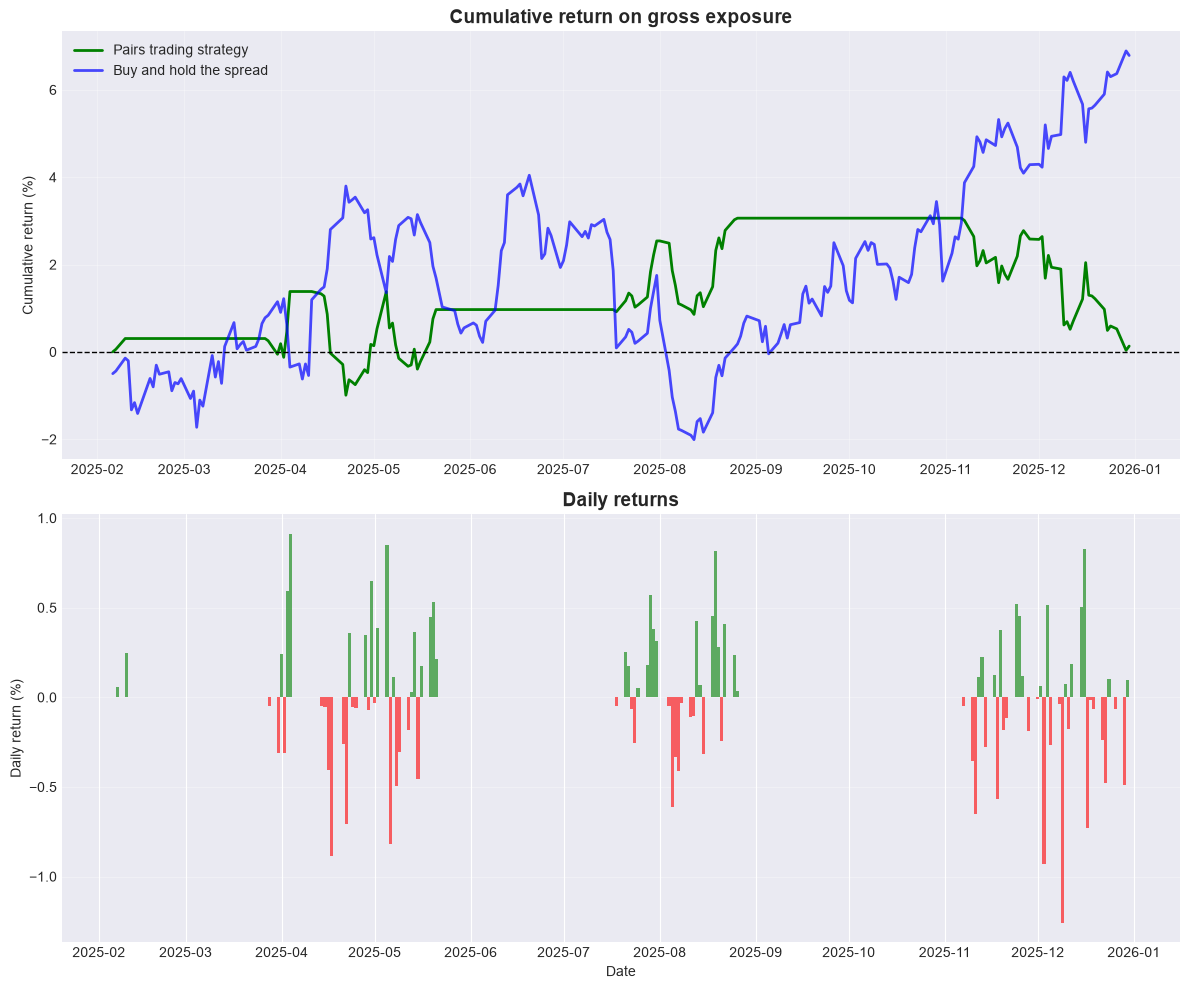

In [18]:
# Step 4: P&L, with transaction costs, on a correct capital base.
#
# THE DENOMINATOR MATTERS. Holding one unit of the spread means being long 1 share of
# asset 2 and short hedge_ratio shares of asset 1, so the capital at risk is the GROSS
# EXPOSURE  G_t = P2_t + |h| * P1_t,  not the spread value S_t = P2_t - h * P1_t.
#
# Using spread.pct_change() as the strategy return, as an earlier version did, is wrong
# twice over: the spread is a price DIFFERENCE, so it has no reason to be positive and can
# pass through zero (unbounded returns, and no meaning at all once it changes sign); and
# even when it stays positive, S is the wrong capital base. Here S ~ $34 against G ~ $185,
# so dividing by S inflates every return roughly fivefold and shrinks the cost drag to match.

commission_rate = 0.00001   # 0.001% per unit of notional traded
slippage_rate = 0.0005      # 0.05%  per unit of notional traded

# Gross exposure per unit of spread held: the capital the position actually ties up.
gross_exposure = price2.abs() + abs(hedge_ratio) * price1.abs()

# Dollar P&L of holding one unit of the spread for one day, converted to a return on capital.
spread_change = spread.diff()
unit_return = spread_change / gross_exposure.shift(1)

unit_return_test = unit_return.loc[test_data.index]

# Lag the signal: we trade on today's signal at tomorrow's prices. This is what keeps the
# backtest free of look-ahead bias.
lagged_signals = signals_test.shift(1).fillna(0)
strategy_returns = lagged_signals * unit_return_test

# Costs are charged on the gross notional turned over. Changing position by |d_pi| units
# turns over |d_pi| * G of notional; since returns are already a fraction of G, the cost in
# return units is just |d_pi| * (commission + slippage).
position_changes = signals_test.diff().abs().fillna(0)
transaction_costs = position_changes * (commission_rate + slippage_rate)

net_returns = (strategy_returns - transaction_costs).fillna(0)

# Benchmark: hold the long-spread position permanently (pi = 1), on the same capital base.
# NOT the compounding pct_change of S, which has no financial meaning.
benchmark_returns = unit_return_test.fillna(0)

cumulative_returns = (1 + net_returns).cumprod()
cumulative_spread = (1 + benchmark_returns).cumprod()

print(f"Spread level:     mean ${spread.mean():.2f}, range ${spread.min():.2f} to ${spread.max():.2f}")
print(f"Gross exposure:   mean ${gross_exposure.mean():.2f}   <- the correct capital base")
print(f"Ratio G/S:        {gross_exposure.mean()/spread.mean():.1f}x  "
      f"(the factor by which pct_change(spread) would have overstated returns)")
print(f"\nDaily strategy return: std {net_returns.std()*100:.3f}%, "
      f"annualised vol {net_returns.std()*np.sqrt(252)*100:.1f}%")
print(f"Total transaction costs over the test period: {transaction_costs.sum()*100:.3f}%")

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(cumulative_returns.index, (cumulative_returns - 1) * 100,
             linewidth=2, label='Pairs trading strategy', color='green')
axes[0].plot(cumulative_spread.index, (cumulative_spread - 1) * 100,
             linewidth=2, label='Buy and hold the spread', color='blue', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Cumulative return on gross exposure', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cumulative return (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(net_returns.index, net_returns * 100, width=1, alpha=0.6,
            color=['green' if x > 0 else 'red' for x in net_returns])
axes[1].set_title('Daily returns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Daily return (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Performance metrics, read sceptically

The usual ratios, all return over a measure of risk:
$$
\text{Sharpe} = \frac{\text{return}}{\text{total volatility}},
\quad
\text{Sortino} = \frac{\text{return}}{\text{downside volatility}},
\quad
\text{Calmar} = \frac{\text{return}}{\lvert\text{max drawdown}\rvert} .
$$
Sharpe treats up and down moves the same. Sortino counts only downside. Calmar uses the worst peak-to-trough drop, which is what decides whether an investor stays in.

The sceptical reading matters more than the numbers.

**Compare against just holding the spread.** This decides whether the *timing rules* add anything beyond the *hedge*. If trading in and out on the $z$-score cannot beat a position that is simply long the spread and never trades, the rules add nothing and all the value is in the cointegration. On this sample that is roughly what happens: the spread does the work, the timing does not.

**A market-neutral spread has low volatility, so a small Sharpe can look big or small for the wrong reason.** A modest return over a small volatility can flatter. That is arithmetic, not skill; in practice you would lever to a target volatility.

**The tails are the real risk.** A pairs trade wins small and often, and loses big and rarely, when the relationship breaks. The returns are left-skewed and fat-tailed, and the Sharpe ratio cannot see that. Read the skewness, kurtosis, and max drawdown.

**Selection bias.** The traded pair was chosen because it was the most cointegrated of the four, using the whole sample. The hedge ratio was fitted on training data (good), but the *pair* was picked with knowledge of the future. A clean backtest would pick the pair on training data too.

**The parameter sweep in section 10 is not an optimisation.** It is scored on the test set, so picking its best cell is in-sample fitting. Its real use is to check *stability*, and there is none: the Sharpe swings from negative to near one across the grid, and our chosen thresholds sit near the bottom. That swing is the result, not a nuisance. A strategy this sensitive to a threshold has not shown an edge.

In [19]:
# Step 5: performance metrics.
def calculate_performance_metrics(returns, annual_factor=252):
    """Standard performance battery for a return series.

    Note the returns here are on GROSS EXPOSURE (see section 8), so they are directly
    comparable across the strategy and the benchmark.
    """
    returns = returns.dropna()
    if len(returns) == 0:
        return {}

    total_return = (1 + returns).prod() - 1
    n_years = len(returns) / annual_factor
    annualized_return = (1 + total_return) ** (1 / n_years) - 1

    volatility = returns.std() * np.sqrt(annual_factor)
    sharpe_ratio = annualized_return / volatility if volatility != 0 else 0

    # Sortino: the same numerator, but the denominator counts only downside moves.
    downside_std = returns[returns < 0].std() * np.sqrt(annual_factor)
    sortino_ratio = annualized_return / downside_std if downside_std > 0 else np.nan

    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    win_rate = (returns > 0).sum() / len(returns)
    gross_profit = returns[returns > 0].sum()
    gross_loss = abs(returns[returns < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf

    return {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Volatility (Ann.)': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Win Rate': win_rate,
        'Profit Factor': profit_factor,
        'Skewness': stats.skew(returns),
        'Excess Kurtosis': stats.kurtosis(returns),
    }

strategy_metrics = calculate_performance_metrics(net_returns)
benchmark_metrics = calculate_performance_metrics(benchmark_returns)

metrics_df = pd.DataFrame({
    'Pairs Trading Strategy': strategy_metrics,
    'Buy-and-Hold Spread': benchmark_metrics,
})

print("Performance metrics, test period (returns on gross exposure)")
print("-" * 70)
print(metrics_df.to_string())

num_trades = int((signals_test.diff().abs() > 0).sum())
print("\nTrade statistics:")
print(f"- Number of trades: {num_trades}")
print(f"- Total transaction costs: {transaction_costs.sum()*100:.4f}%")
print(f"- Time in market: {(signals_test != 0).sum() / len(signals_test) * 100:.1f}%")
if num_trades > 0:
    print(f"- Average holding period: {(signals_test != 0).sum() / (num_trades / 2):.1f} days")

# The comparison that actually matters: does the TIMING SIGNAL beat simply holding the
# spread and never trading? If it does not, all the value was in the cointegration
# relationship (the hedge), and none of it in the entry/exit rules.
s_strat = strategy_metrics['Sharpe Ratio']
s_bench = benchmark_metrics['Sharpe Ratio']
print(f"\nThe decisive comparison: strategy Sharpe {s_strat:.2f} "
      f"against buy-and-hold-the-spread Sharpe {s_bench:.2f}")
if s_strat < s_bench:
    print("=> The z-score timing rules ADD NOTHING over simply holding the spread. All the")
    print("   value here is in the cointegration relationship, not in the entry and exit")
    print("   signals layered on top of it. A backtest that reported only its own equity")
    print("   curve, with no benchmark, would have quietly concealed this.")
else:
    print("=> The timing rules do add value over a static long-spread position.")

print("""
Read this table sceptically:

- A market-neutral spread has low volatility, so a modest return divided by a small
  denominator produces a flattering Sharpe. That is arithmetic, not alpha. In practice
  such a strategy is levered to a target volatility, which restores the risk pro rata.

- Look at the SKEWNESS and the MAX DRAWDOWN, not the Sharpe. A pairs trade wins small and
  often, and loses large and rarely, when the cointegration breaks. The Sharpe ratio uses
  only the first two moments and is therefore blind to exactly the moment that ends the
  strategy.

- The pair being traded was SELECTED because it tested as the most cointegrated of the
  four, using the whole sample. The hedge ratio was fitted on training data only, which is
  right, but the choice of pair still peeked at the future. A clean backtest would select
  the pair on the training window alone.""")

Performance metrics, test period (returns on gross exposure)
----------------------------------------------------------------------
                   Pairs Trading Strategy  Buy-and-Hold Spread
Total Return                     0.001329             0.067860
Annualized Return                0.001482             0.075956
Volatility (Ann.)                0.042495             0.074848
Sharpe Ratio                     0.034879             1.014801
Sortino Ratio                    0.033040             1.557078
Max Drawdown                    -0.029357            -0.058179
Calmar Ratio                     0.050488             1.305551
Win Rate                         0.207965             0.548673
Profit Factor                    1.014006             1.182387
Skewness                        -0.429775            -0.083047
Excess Kurtosis                  4.641855             1.203579

Trade statistics:
- Number of trades: 10
- Total transaction costs: 0.5100%
- Time in market: 41.6%
- Average h

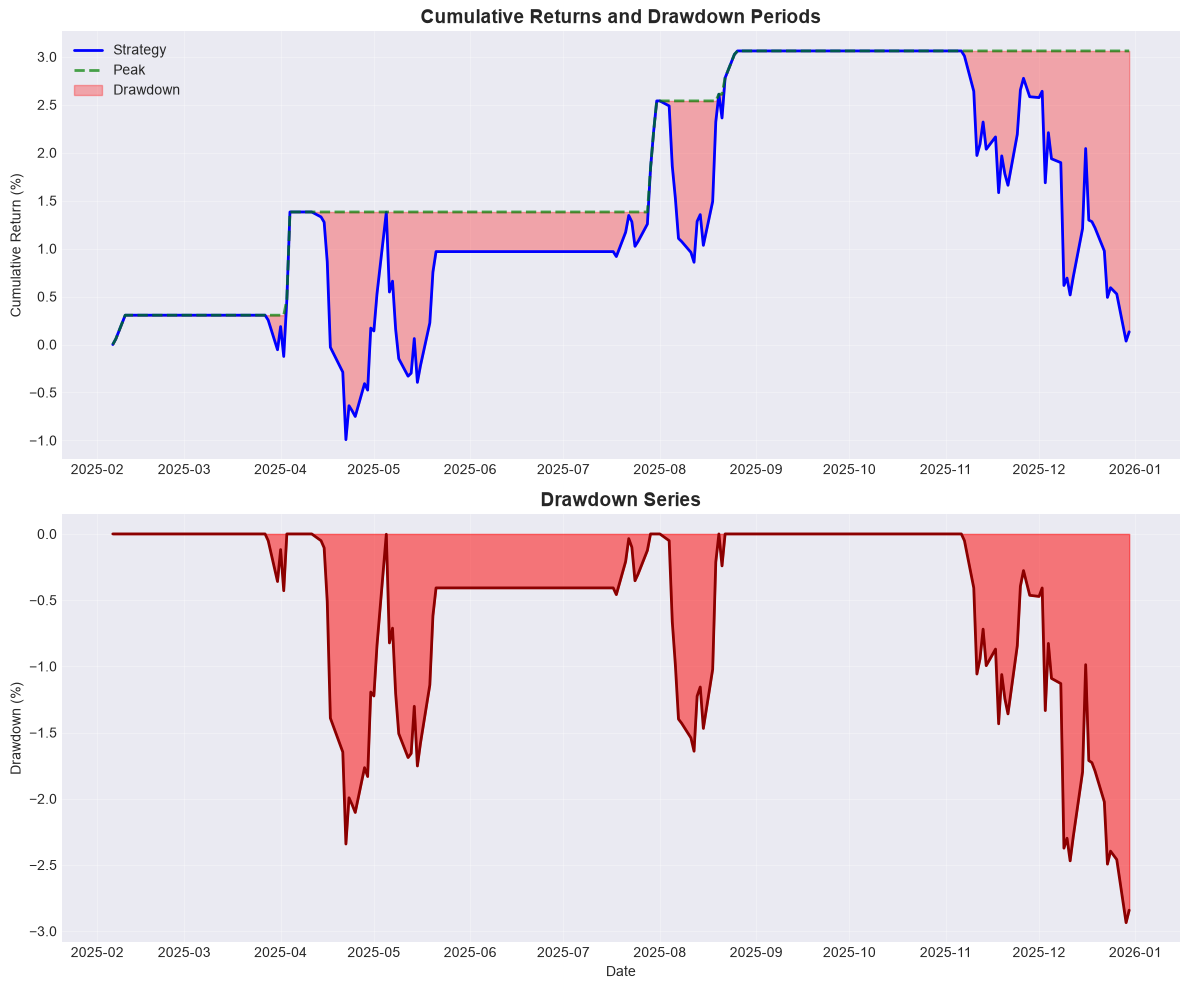


Maximum Drawdown: -2.94%
Occurred on: 2025-12-29


In [20]:
# Drawdown analysis
cumulative = (1 + net_returns).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Cumulative returns with drawdown periods
axes[0].plot(cumulative.index, (cumulative - 1) * 100, linewidth=2, label='Strategy', color='blue')
axes[0].plot(running_max.index, (running_max - 1) * 100, linewidth=2, 
            linestyle='--', label='Peak', color='green', alpha=0.7)
axes[0].fill_between(cumulative.index, (cumulative - 1) * 100, (running_max - 1) * 100, 
                     alpha=0.3, color='red', label='Drawdown')
axes[0].set_title('Cumulative Returns and Drawdown Periods', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown series
axes[1].fill_between(drawdown.index, drawdown * 100, 0, alpha=0.5, color='red')
axes[1].plot(drawdown.index, drawdown * 100, linewidth=2, color='darkred')
axes[1].set_title('Drawdown Series', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find largest drawdown period
max_dd_idx = drawdown.idxmin()
max_dd_value = drawdown.min()
print(f"\nMaximum Drawdown: {max_dd_value*100:.2f}%")
print(f"Occurred on: {max_dd_idx.date()}")

## 10. Parameter sensitivity

We vary the entry and exit thresholds over a grid and record the Sharpe ratio at each.

To repeat the section 9 warning, because it is how backtests most often lie: **this table is not for finding the best parameters.** It is scored on the test set, so picking the maximum is in-sample fitting, and no one choosing thresholds in advance could have achieved it. With nine noisy cells, the best is biased upward.

The real use is to check for **flatness**:

- Is performance positive across most of the grid, or only one cell?
- Do the neighbours of the best cell look reasonable, or does it fall off a cliff?
- Does the trade count fall as the entry threshold rises, as it must?

A Sharpe of $1.8$ at one threshold and $-0.3$ at the next has found a quirk of this sample, not an effect. Values like $0.9, 1.1, 0.8$ across neighbours are more believable even with a lower peak. A flat neighbourhood beats a lucky peak.

In [21]:
# Parameter sensitivity across a grid of entry/exit thresholds.
#
# THIS IS NOT AN OPTIMISATION, despite appearances. The grid is scored on the TEST set, so
# picking its maximum is in-sample fitting by another name, and with 9 noisy cells the
# maximum is upward-biased almost by construction. Nobody choosing parameters in advance
# could have achieved the best number below.
#
# The legitimate use is to look for FLATNESS: is the strategy positive across most of the
# grid, or only in one lucky cell? A lower peak with well-behaved neighbours beats a higher
# peak on a knife edge, every time.

print("Parameter sensitivity analysis")
print("-" * 70)

entry_thresholds = [1.5, 2.0, 2.5]
exit_thresholds = [0.25, 0.5, 0.75]

sensitivity_results = []

for entry_th in entry_thresholds:
    for exit_th in exit_thresholds:
        signals_temp = generate_signals(z_score, entry_threshold=entry_th,
                                        exit_threshold=exit_th).loc[test_data.index]

        # Same P&L construction as section 8: dollar change in the spread, per unit of
        # spread held, divided by the gross exposure that unit ties up.
        lagged_temp = signals_temp.shift(1).fillna(0)
        strategy_returns_temp = lagged_temp * unit_return_test

        position_changes_temp = signals_temp.diff().abs().fillna(0)
        costs_temp = position_changes_temp * (commission_rate + slippage_rate)

        net_returns_temp = (strategy_returns_temp - costs_temp).fillna(0)
        metrics_temp = calculate_performance_metrics(net_returns_temp)

        sensitivity_results.append({
            'Entry': entry_th,
            'Exit': exit_th,
            'Sharpe Ratio': metrics_temp['Sharpe Ratio'],
            'Annualized Return': metrics_temp['Annualized Return'],
            'Max Drawdown': metrics_temp['Max Drawdown'],
            'Trades': int((position_changes_temp > 0).sum()),
        })

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df.round(4).to_string(index=False))

sharpes = sensitivity_df['Sharpe Ratio']
n_positive = int((sharpes > 0).sum())

print(f"\nSharpe ratio across the grid: min {sharpes.min():.2f}, "
      f"median {sharpes.median():.2f}, max {sharpes.max():.2f}")
print(f"Positive in {n_positive} of {len(sharpes)} cells.")
print("\nRead this for FLATNESS, not for its maximum:")
if n_positive >= 0.8 * len(sharpes) and sharpes.min() > -0.5:
    print("- Performance is positive nearly everywhere and degrades gracefully. That is")
    print("  what a robust effect looks like, and it is more reassuring than the peak.")
else:
    print("- Performance is positive in only some cells, so the result depends materially")
    print("  on the thresholds. That is the signature of a sample artefact rather than a")
    print("  durable effect. Treat the headline Sharpe with suspicion.")
print("- The trade count should fall as the entry threshold rises (a higher bar means")
print("  fewer signals). If it does not, the signal logic is suspect.")

Parameter sensitivity analysis
----------------------------------------------------------------------
 Entry  Exit  Sharpe Ratio  Annualized Return  Max Drawdown  Trades
   1.5  0.25        0.1025             0.0059       -0.0543      12
   1.5  0.50        0.7325             0.0378       -0.0341      16
   1.5  0.75        0.9911             0.0476       -0.0294      17
   2.0  0.25        0.2266             0.0111       -0.0294      10
   2.0  0.50        0.0349             0.0015       -0.0294      10
   2.0  0.75       -0.1425            -0.0056       -0.0294       9
   2.5  0.25        0.5402             0.0237       -0.0267       6
   2.5  0.50        0.2897             0.0105       -0.0267       5
   2.5  0.75        0.3315             0.0108       -0.0267       5

Sharpe ratio across the grid: min -0.14, median 0.29, max 0.99
Positive in 8 of 9 cells.

Read this for FLATNESS, not for its maximum:
- Performance is positive nearly everywhere and degrades gracefully. That is
  wha

## 11. Principal component analysis

The last approach: instead of *modelling* the dependence among many assets, **decompose** it.

Standardise each asset's returns to mean $0$ and variance $1$, and form the correlation matrix $\Sigma$. PCA finds the directions that capture the most variance, one after another, each orthogonal to the last. These directions are the **eigenvectors** of $\Sigma$, and the variance each captures is its **eigenvalue** $\lambda_i$. Since $\Sigma$ has trace $k$, the fraction of variance in component $i$ is $\lambda_i / k$.

**Why standardise?** PCA chases variance, so without standardising, the biggest-volatility assets would dominate and we would be measuring units, not structure. Standardising makes it a decomposition of the *correlation* matrix.

**What the components mean.**

- **PC1** has the same sign on almost every stock and explains a lot of the variance (often 30 to 60% for a diversified portfolio). This is the **market factor**, and its time series is essentially the market return. That it appears from nothing but a correlation matrix is the empirical basis of the CAPM.
- **PC2 and PC3** usually split along sector or style lines (positive on one group, negative on another). Watch for energy separating from tech here.
- The rest is closer to noise.

**The payoff.** If five components explain 80% of the variance of twenty stocks, the portfolio holds about five independent bets, not twenty. That is the honest measure of diversification, usually far smaller than the number of positions. It is also why factor models work on components: a 500-asset covariance matrix has over 100,000 free numbers, but a five-factor model needs far fewer.

A caution. The loadings are not stable, and in practice they are re-estimated over rolling windows, the same instability we saw in section 9 of [stylized_facts_of_asset_returns.ipynb](stylized_facts_of_asset_returns.ipynb). And PCA is linear and based on covariances, so like everything here it says nothing about the tail dependence that the first notebook found to be the main risk in a crash.

In [22]:
# Download stock data for a diversified portfolio
print("Downloading stock data...")

tickers = {
    'Tech': ['AAPL', 'MSFT', 'GOOGL', 'NVDA'],
    'Finance': ['JPM', 'BAC', 'GS', 'WFC'],
    'Consumer': ['AMZN', 'WMT', 'HD', 'MCD'],
    'Healthcare': ['JNJ', 'UNH', 'PFE', 'ABBV'],
    'Energy': ['XOM', 'CVX', 'COP', 'SLB']
}

all_tickers = [ticker for sector in tickers.values() for ticker in sector]

# Download data
stock_data = yf.download(all_tickers, start='2016-01-01', end='2025-12-31', progress=False, auto_adjust=False)
prices = stock_data['Adj Close'].dropna()

# Calculate log returns
returns = np.log(prices / prices.shift(1)).dropna() * 100

print(f"\nSample period: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Number of observations: {len(returns)}")
print(f"Number of stocks: {len(all_tickers)}")
print(f"\nSectors and stocks:")
for sector, stocks in tickers.items():
    print(f"- {sector}: {', '.join(stocks)}")


Sample period: 2016-01-05 to 2025-12-30
Number of observations: 2512
Number of stocks: 20

Sectors and stocks:
- Tech: AAPL, MSFT, GOOGL, NVDA
- Finance: JPM, BAC, GS, WFC
- Consumer: AMZN, WMT, HD, MCD
- Healthcare: JNJ, UNH, PFE, ABBV
- Energy: XOM, CVX, COP, SLB


In [23]:
# Perform PCA on the return dataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\nPrincipal Component Analysis")
print("-" * 70)

# Standardize returns (important for PCA)
# This is to standardize data by calculating the mean and standard deviation of a dataset and then applying the transformation (mean subtraction and division by standard deviation)
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

# Fit PCA
n_components = 10  # Extract first 10 components
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(returns_scaled)

# Convert to DataFrame
pc_df = pd.DataFrame(
    principal_components,
    index=returns.index,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print(f"Number of original features: {returns.shape[1]}")
print(f"Number of principal components: {n_components}")
print(f"\nExplained variance ratio by component:")
for i, var_ratio in enumerate(pca.explained_variance_ratio_):
    print(f"- PC{i+1}: {var_ratio*100:.2f}%")

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"\nCumulative explained variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"- First {i+1} PCs: {cum_var*100:.2f}%")


Principal Component Analysis
----------------------------------------------------------------------
Number of original features: 20
Number of principal components: 10

Explained variance ratio by component:
- PC1: 42.33%
- PC2: 12.04%
- PC3: 8.04%
- PC4: 5.93%
- PC5: 4.31%
- PC6: 3.73%
- PC7: 3.12%
- PC8: 2.92%
- PC9: 2.52%
- PC10: 2.28%

Cumulative explained variance:
- First 1 PCs: 42.33%
- First 2 PCs: 54.37%
- First 3 PCs: 62.41%
- First 4 PCs: 68.35%
- First 5 PCs: 72.66%
- First 6 PCs: 76.39%
- First 7 PCs: 79.50%
- First 8 PCs: 82.42%
- First 9 PCs: 84.94%
- First 10 PCs: 87.22%


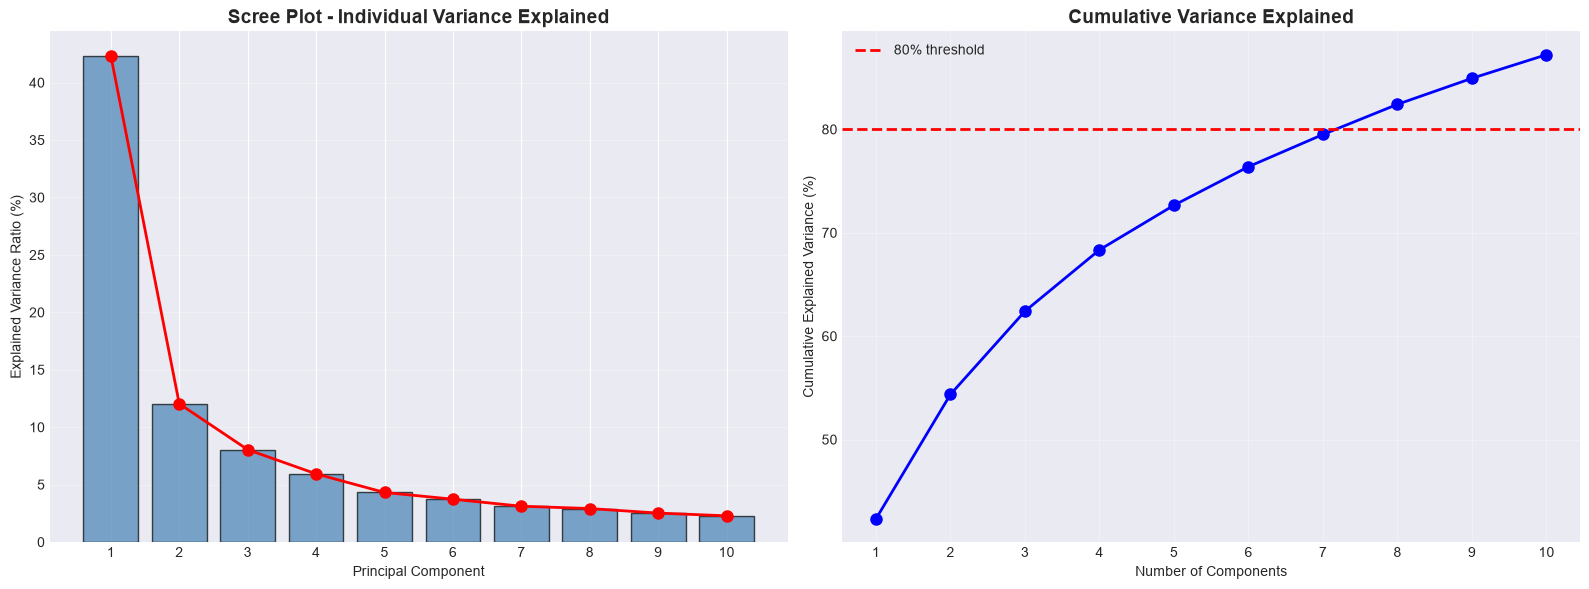


Number of components needed for 80% variance: 8
Dimension reduction: 20 → 8 (40.0%)


In [24]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, n_components+1), pca.explained_variance_ratio_ * 100, 
           alpha=0.7, color='steelblue', edgecolor='black')
axes[0].plot(range(1, n_components+1), pca.explained_variance_ratio_ * 100, 
            'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio (%)')
axes[0].set_title('Scree Plot - Individual Variance Explained', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, n_components+1))
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative explained variance
axes[1].plot(range(1, n_components+1), cumulative_variance * 100, 
            'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, 
               label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, n_components+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"\nNumber of components needed for 80% variance: {n_components_80}")
print(f"Dimension reduction: {returns.shape[1]} → {n_components_80} ({n_components_80/returns.shape[1]*100:.1f}%)")


Factor Loadings (Top 5 stocks by absolute loading):
----------------------------------------------------------------------

PC1 (explains 42.33% variance):
  JPM   :  0.2823
  BAC   :  0.2798
  GS    :  0.2793
  WFC   :  0.2615
  CVX   :  0.2564

PC2 (explains 12.04% variance):
  AMZN  :  0.3514
  MSFT  :  0.3369
  XOM   : -0.3261
  SLB   : -0.3174
  COP   : -0.3113

PC3 (explains 8.04% variance):
  JNJ   :  0.4819
  PFE   :  0.4339
  ABBV  :  0.3769
  NVDA  : -0.2771
  UNH   :  0.2721


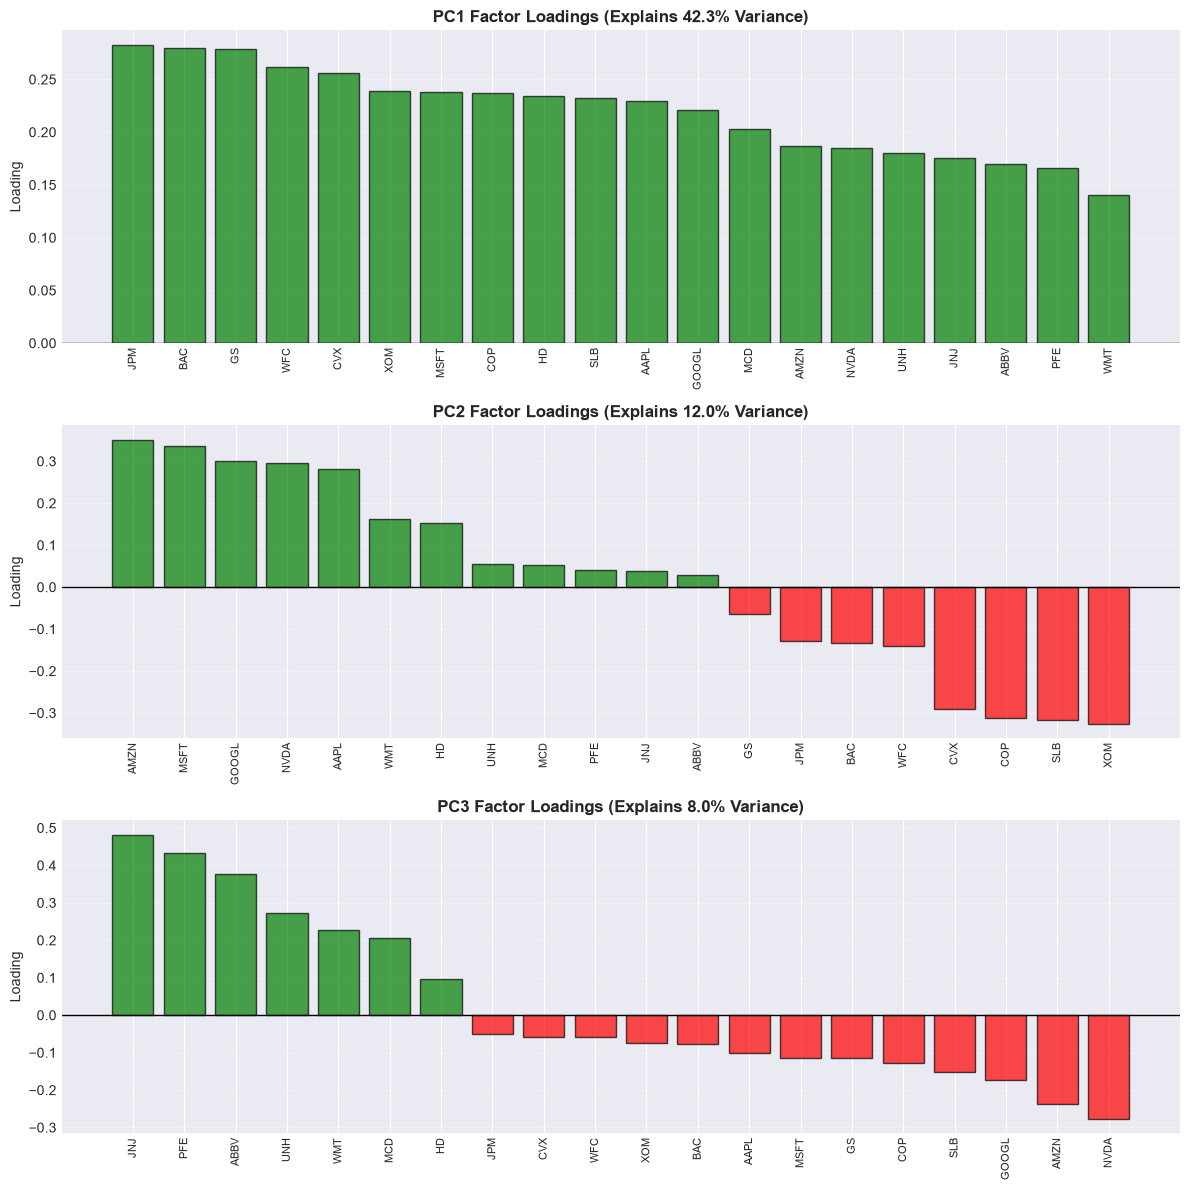

In [25]:
# Analyze factor loadings (component weights)
loadings = pd.DataFrame(
    pca.components_.T,
    index=returns.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print("\nFactor Loadings (Top 5 stocks by absolute loading):")
print("-" * 70)

for i in range(min(3, n_components)):  # Show first 3 PCs
    pc_name = f'PC{i+1}'
    top_loadings = loadings[pc_name].abs().nlargest(5)
    
    print(f"\n{pc_name} (explains {pca.explained_variance_ratio_[i]*100:.2f}% variance):")
    for stock, loading_val in top_loadings.items():
        actual_loading = loadings.loc[stock, pc_name]
        print(f"  {stock:6s}: {actual_loading:7.4f}") # 6s: left-aligned as a string with a minimum width of 6 characters
                                                      # 7.4f: a float with a total width of 7 characters (including the decimal point and digits) and exactly 4 digits after the decimal point

# Visualize loadings for first 3 PCs
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i in range(3):
    pc_name = f'PC{i+1}'
    loadings_sorted = loadings[pc_name].sort_values(ascending=False)
    
    colors = ['green' if x > 0 else 'red' for x in loadings_sorted]
    axes[i].bar(range(len(loadings_sorted)), loadings_sorted, 
               color=colors, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{pc_name} Factor Loadings (Explains {pca.explained_variance_ratio_[i]*100:.1f}% Variance)',
                     fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Loading')
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].set_xticks(range(len(loadings_sorted)))
    axes[i].set_xticklabels(loadings_sorted.index, rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

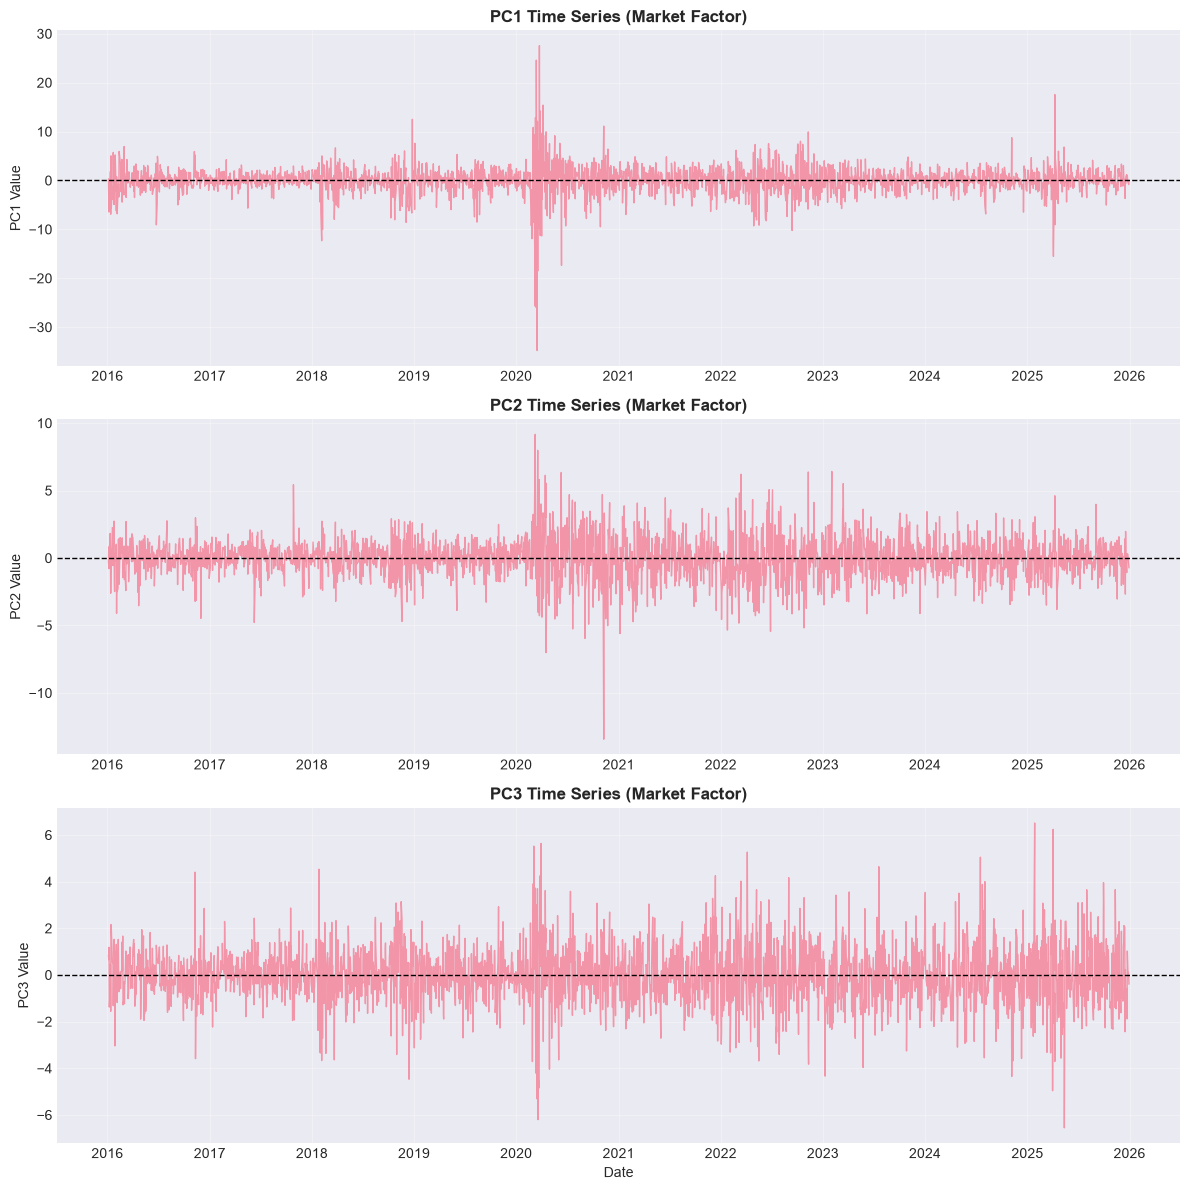


Interpretation:
- PC1: Market factor - common movement across all stocks
- PC2-PC3: Sector or style factors - capturing sector-specific risks


In [26]:
# Visualize principal component time series
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i in range(3):
    pc_name = f'PC{i+1}'
    axes[i].plot(pc_df.index, pc_df[pc_name], linewidth=1, alpha=0.7)
    axes[i].set_title(f'{pc_name} Time Series (Market Factor)', 
                     fontsize=12, fontweight='bold')
    axes[i].set_ylabel(f'{pc_name} Value')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Interpretation: PC1 typically represents "market factor"
print("\nInterpretation:")
print("- PC1: Market factor - common movement across all stocks")
print("- PC2-PC3: Sector or style factors - capturing sector-specific risks")

## Summary

Three ways to bring in a second series, answering different questions.

**VAR and Granger causality** describe lead-lag structure among stationary series. On daily ETF returns the effects are detectable but tiny, which is what an efficient market looks like. Two lessons: the multiple-testing trap of scanning lags for the smallest p-value (which invented five "causal" links out of twenty), and the identification problem, where the Cholesky order is an assumption, not a finding.

**Cointegration** is the stronger idea, because it finds predictability where the individual series have none. Two random walks with a common trend have a stationary, mean-reverting, tradeable spread. Differencing to returns destroys it, since the correction term lives in the *levels*.

The pairs-trading backtest is where theory meets reality, and the reality is humbling. Getting the P&L denominator right (gross exposure, not the spread) matters more than any signal tweak. The pair was picked using the test period. The Sharpe swings from negative to near one across the grid, so the headline number is a draw from that range. And most tellingly, the timing rules do not beat simply holding the spread, so the value is in the cointegration, not the trading rules. The risk that would actually end the strategy, the pair decointegrating, appears in none of our statistics, because it has not happened yet in this sample.

**PCA** decomposes rather than models, and gives the most useful single number for a portfolio: how many independent bets are really on. Usually far fewer than the number of positions.

**What the whole repository keeps circling.** Returns are unpredictable in the mean but predictable in the variance. Assets move together in the tails far more than any correlation says. And every model here is linear, assumes normal errors for its inference, and is fitted on a sample where the relationship has not yet broken. Each of those is where the next thing goes wrong.